# ⚽ K-Means Clustering — Gaya Bermain Klub La Liga

---

## 📋 Deskripsi Notebook

Notebook ini merupakan tahap **Machine Learning** dalam penelitian skripsi Data Engineering yang menganalisis gaya bermain klub-klub La Liga.

**Tujuan:**
- Mengelompokkan 20 klub La Liga berdasarkan **10 style scores** menggunakan algoritma **K-Means Clustering**.
- Mengidentifikasi **karakteristik taktis** yang membedakan setiap kelompok.
- Menghasilkan interpretasi yang dapat digunakan pada dashboard analitik dan analisis gaya bermain.

**Input:**
- File `data/ml_ready/teams_style_scores.csv` — dataset hasil notebook sebelumnya (Style Scoring), berisi **club + 10 style scores** (skala 0–100).

**Output:**
- Label cluster untuk setiap klub
- Visualisasi cluster (PCA, radar, heatmap)
- Interpretasi karakteristik setiap cluster

**Alur Keseluruhan Penelitian:**
```
Notebook 01: Feature Engineering & Style Scoring
        ↓
Notebook 02: K-Means Clustering  ← (notebook ini)
```

> ⚠️ Notebook ini **tidak mengulang** proses feature engineering. Data sudah bersih dan siap digunakan.

---

## 1. Import Library

Library yang digunakan:
- **pandas** & **numpy** — manipulasi data dan komputasi numerik
- **matplotlib** & **seaborn** — visualisasi statis
- **scikit-learn** — StandardScaler, KMeans, PCA, Silhouette Score

In [30]:
# === Data Manipulation ===
import numpy as np
import pandas as pd
from pathlib import Path

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# === Machine Learning ===
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# === Settings ===
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Seed untuk reproducibility
RANDOM_STATE = 42

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


---

## 2. Load Dataset

Dataset `teams_style_scores.csv` berisi **20 klub × 11 kolom** (1 kolom `club` + 10 style scores).  
Dataset ini merupakan output dari notebook *Style Scoring* sebelumnya.

In [31]:
# --- Load Dataset ---
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "ml_ready" / "teams_style_scores.csv"

df = pd.read_csv(data_path)

print(f"✅ Dataset berhasil dimuat dari: {data_path.name}")
print(f"   Shape: {df.shape[0]} klub × {df.shape[1]} kolom")

✅ Dataset berhasil dimuat dari: teams_style_scores.csv
   Shape: 20 klub × 11 kolom


In [32]:
# --- Preview ---
df.head()

,club,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
0,Alaves,36.07,29.19,38.65,42.75,58.82,30.49,30.53,55.21,61.87,27.11
1,Athletic Bilbao,36.19,26.54,47.68,73.22,61.00,48.81,32.40,34.02,54.28,38.08
2,Atlético Madrid,64.13,58.54,38.98,35.33,58.04,61.09,61.77,51.70,70.46,33.93
3,Barcelona,99.80,93.75,32.82,72.06,50.73,91.06,100.00,57.58,89.50,45.88
4,Celta Vigo,64.03,54.75,31.21,22.05,47.38,34.87,62.05,8.21,48.11,23.52


In [33]:
# --- Info ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   club                        20 non-null     str    
 1   possession_score            20 non-null     float64
 2   attacking_efficiency_score  20 non-null     float64
 3   direct_play_score           20 non-null     float64
 4   pressing_score              20 non-null     float64
 5   defensive_solidity_score    20 non-null     float64
 6   chance_creation_score       20 non-null     float64
 7   build_up_score              20 non-null     float64
 8   set_piece_score             20 non-null     float64
 9   discipline_score            20 non-null     float64
 10  counter_attack_score        20 non-null     float64
dtypes: float64(10), str(1)
memory usage: 2.0 KB


---

## 3. Exploratory Data Analysis (EDA)

Sebelum melakukan clustering, kita perlu memahami **karakteristik dataset** secara keseluruhan.  
Tahap ini membantu memvalidasi bahwa data sudah siap untuk diproses oleh algoritma K-Means.

In [34]:
# --- Pemeriksaan dasar ---
score_cols = [c for c in df.columns if c != "club"]

print("📊 Ringkasan Dataset")
print("=" * 40)
print(f"   Jumlah klub    : {df.shape[0]}")
print(f"   Jumlah fitur   : {len(score_cols)}")
print(f"   Missing values : {df.isnull().sum().sum()}")
print(f"   Duplicate rows : {df.duplicated().sum()}")
print(f"   Fitur: {score_cols}")

📊 Ringkasan Dataset
   Jumlah klub    : 20
   Jumlah fitur   : 10
   Missing values : 0
   Duplicate rows : 0
   Fitur: ['possession_score', 'attacking_efficiency_score', 'direct_play_score', 'pressing_score', 'defensive_solidity_score', 'chance_creation_score', 'build_up_score', 'set_piece_score', 'discipline_score', 'counter_attack_score']


In [35]:
# --- Statistik deskriptif ---
df[score_cols].describe().round(2)

,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,46.97,40.71,43.74,38.19,52.47,38.50,42.81,44.96,56.21,39.86
std,22.41,21.63,10.38,18.54,11.17,19.77,22.93,24.94,16.29,15.30
min,0.00,7.37,27.77,9.16,36.38,5.79,0.00,8.21,22.75,21.94
25%,36.16,27.04,37.19,25.07,44.27,30.24,31.00,25.48,47.48,29.94
50%,41.51,33.10,45.45,36.09,52.36,33.50,34.58,47.48,54.76,39.50
75%,60.66,54.96,48.76,46.18,60.53,40.70,54.86,59.82,67.41,42.82
max,99.80,93.75,63.81,73.22,73.37,91.06,100.00,88.06,89.50,82.96


### 3.1 Distribusi Setiap Style Score

Histogram di bawah menampilkan persebaran nilai untuk setiap style score.  
Tujuannya adalah memeriksa apakah fitur memiliki variasi yang cukup untuk membedakan antar klub.

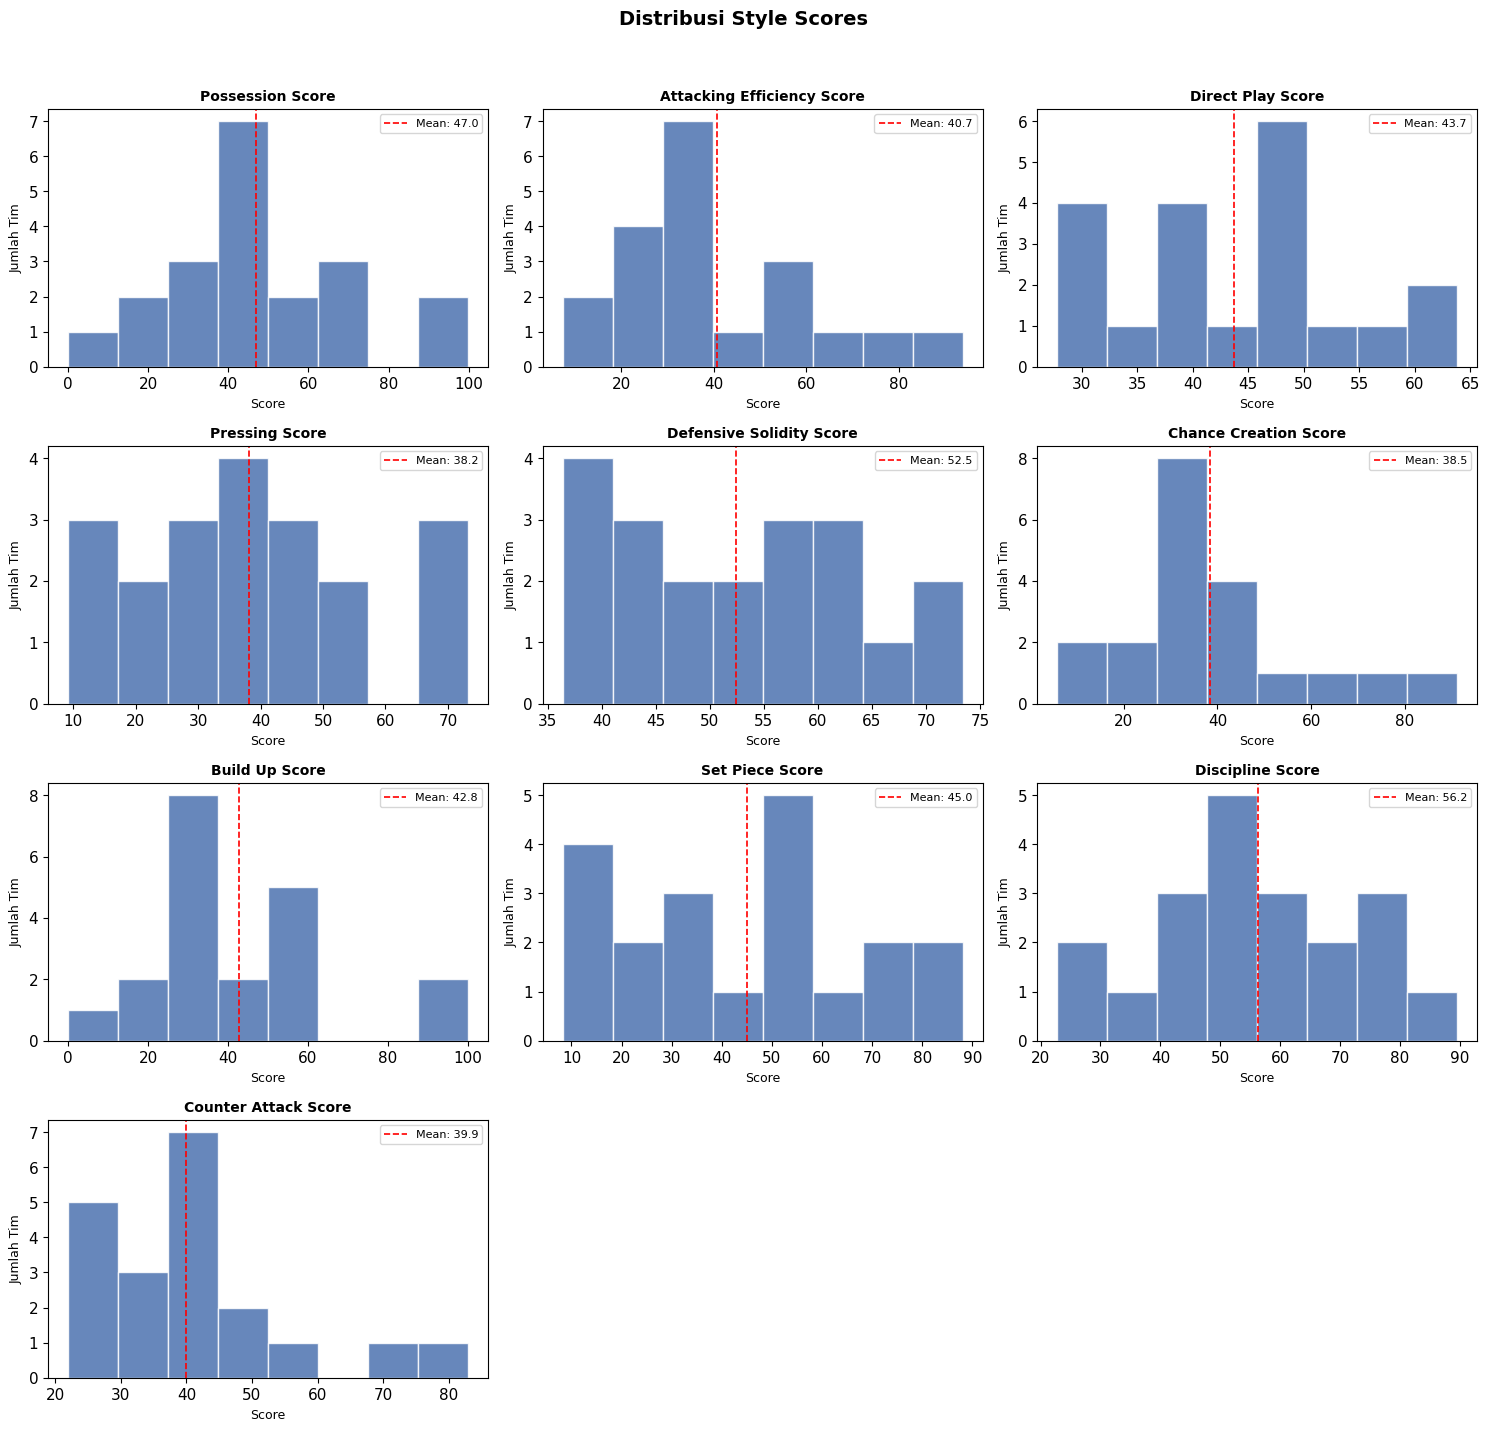

In [36]:
# --- Histogram distribusi ---
n_cols_grid = 3
n_rows_grid = (len(score_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, n_rows_grid * 3.5))
fig.suptitle("Distribusi Style Scores", fontsize=14, fontweight="bold", y=1.02)

for idx, col in enumerate(score_cols):
    ax = axes.flat[idx]
    ax.hist(df[col], bins=8, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.2, label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Jumlah Tim", fontsize=9)
    ax.legend(fontsize=8)

for idx in range(len(score_cols), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Correlation Heatmap

Korelasi antar style scores menunjukkan hubungan linear antar dimensi gaya bermain.  
Korelasi yang sangat tinggi (|r| > 0.9) bisa mengindikasikan redundansi fitur, sedangkan korelasi rendah menunjukkan fitur saling independen dan menangkap aspek yang berbeda.

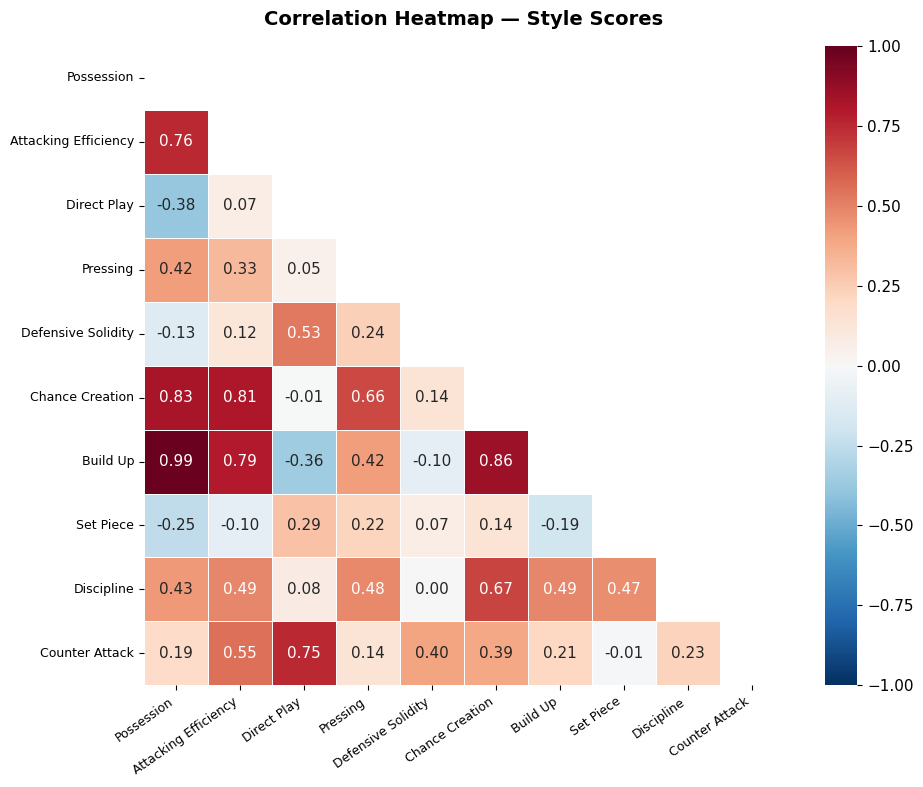

In [37]:
# --- Correlation Heatmap ---
corr = df[score_cols].corr()

# Label pendek
short_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hanya segitiga bawah

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    xticklabels=short_labels,
    yticklabels=short_labels,
    square=True,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Correlation Heatmap — Style Scores", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

---

## 4. Feature Selection

Fitur yang digunakan untuk clustering adalah **10 style scores** berikut:

| No | Fitur | Deskripsi |
|----|-------|----------|
| 1 | `possession_score` | Dominasi penguasaan bola |
| 2 | `attacking_efficiency_score` | Efektivitas konversi peluang → gol |
| 3 | `direct_play_score` | Kecenderungan bermain cepat & vertikal |
| 4 | `pressing_score` | Intensitas tekanan terhadap lawan |
| 5 | `defensive_solidity_score` | Kualitas pertahanan |
| 6 | `chance_creation_score` | Kemampuan menciptakan peluang |
| 7 | `build_up_score` | Kemampuan membangun serangan bertahap |
| 8 | `set_piece_score` | Ancaman dari bola mati |
| 9 | `discipline_score` | Kedisiplinan & minimnya kesalahan |
| 10 | `counter_attack_score` | Efektivitas serangan balik |

### Mengapa Hanya Style Score?

1. **Sudah merupakan representasi terkompresi** — Setiap score sudah merangkum beberapa indikator statistik mentah menjadi satu dimensi yang bermakna.
2. **Skala konsisten** — Semua score sudah berada pada rentang 0–100 (hasil normalisasi Min-Max + weighted average dari notebook sebelumnya).
3. **Interpretabilitas tinggi** — Setiap dimensi memiliki makna taktis yang jelas sehingga hasil clustering mudah dijelaskan.
4. **Kolom `club`** tidak digunakan sebagai fitur karena merupakan identifier, bukan variabel numerik.

In [38]:
# --- Siapkan matriks fitur (X) ---
X = df[score_cols].copy()

print(f"✅ Matriks fitur X:")
print(f"   Shape : {X.shape}")
print(f"   Fitur : {list(X.columns)}")

✅ Matriks fitur X:
   Shape : (20, 10)
   Fitur : ['possession_score', 'attacking_efficiency_score', 'direct_play_score', 'pressing_score', 'defensive_solidity_score', 'chance_creation_score', 'build_up_score', 'set_piece_score', 'discipline_score', 'counter_attack_score']


---

## 5. Feature Scaling — StandardScaler

### Mengapa Scaling Diperlukan?

Algoritma K-Means menghitung jarak antar titik data menggunakan **Euclidean Distance**.  
Meskipun semua style score sudah berada pada rentang 0–100, distribusi nilai antar fitur bisa sangat berbeda:
- Fitur dengan **standar deviasi besar** akan mendominasi perhitungan jarak.
- Fitur dengan **standar deviasi kecil** akan terabaikan.

Scaling memastikan setiap fitur berkontribusi secara **proporsional** terhadap pembentukan cluster.

### Mengapa StandardScaler?

**StandardScaler** mentransformasi setiap fitur agar memiliki:
- **Mean = 0** (berpusat di nol)
- **Standard Deviation = 1** (unit variance)

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

StandardScaler dipilih karena:
1. **Standar dalam K-Means** — Sebagian besar literatur dan implementasi K-Means menggunakan StandardScaler.
2. **Tidak membatasi range** — Tidak memaksa data ke rentang tertentu, sehingga outlier tetap terwakili.
3. **Cocok untuk data yang sudah relatif normal** — Style scores sudah melalui normalisasi, sehingga tidak ada skewness ekstrem.

In [39]:
# --- Sebelum Scaling ---
print("📊 SEBELUM Scaling:")
print(X.describe().round(2).loc[["mean", "std", "min", "max"]])
print()

📊 SEBELUM Scaling:
      possession_score  attacking_efficiency_score  direct_play_score  pressing_score  defensive_solidity_score  chance_creation_score  build_up_score  set_piece_score  discipline_score  \
mean             46.97                       40.71              43.74           38.19                     52.47                  38.50           42.81            44.96             56.21   
std              22.41                       21.63              10.38           18.54                     11.17                  19.77           22.93            24.94             16.29   
min               0.00                        7.37              27.77            9.16                     36.38                   5.79            0.00             8.21             22.75   
max              99.80                       93.75              63.81           73.22                     73.37                  91.06          100.00            88.06             89.50   

      counter_attack_score  
mean  

In [40]:
# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Konversi kembali ke DataFrame untuk inspeksi
X_scaled_df = pd.DataFrame(X_scaled, columns=score_cols, index=df.index)

print("📊 SESUDAH Scaling:")
print(X_scaled_df.describe().round(2).loc[["mean", "std", "min", "max"]])

📊 SESUDAH Scaling:
      possession_score  attacking_efficiency_score  direct_play_score  pressing_score  defensive_solidity_score  chance_creation_score  build_up_score  set_piece_score  discipline_score  \
mean             -0.00                       -0.00              -0.00           -0.00                      0.00                  -0.00           -0.00             0.00             -0.00   
std               1.03                        1.03               1.03            1.03                      1.03                   1.03            1.03             1.03              1.03   
min              -2.15                       -1.58              -1.58           -1.61                     -1.48                  -1.70           -1.92            -1.51             -2.11   
max               2.42                        2.52               1.98            1.94                      1.92                   2.73            2.56             1.77              2.10   

      counter_attack_score  
mean  

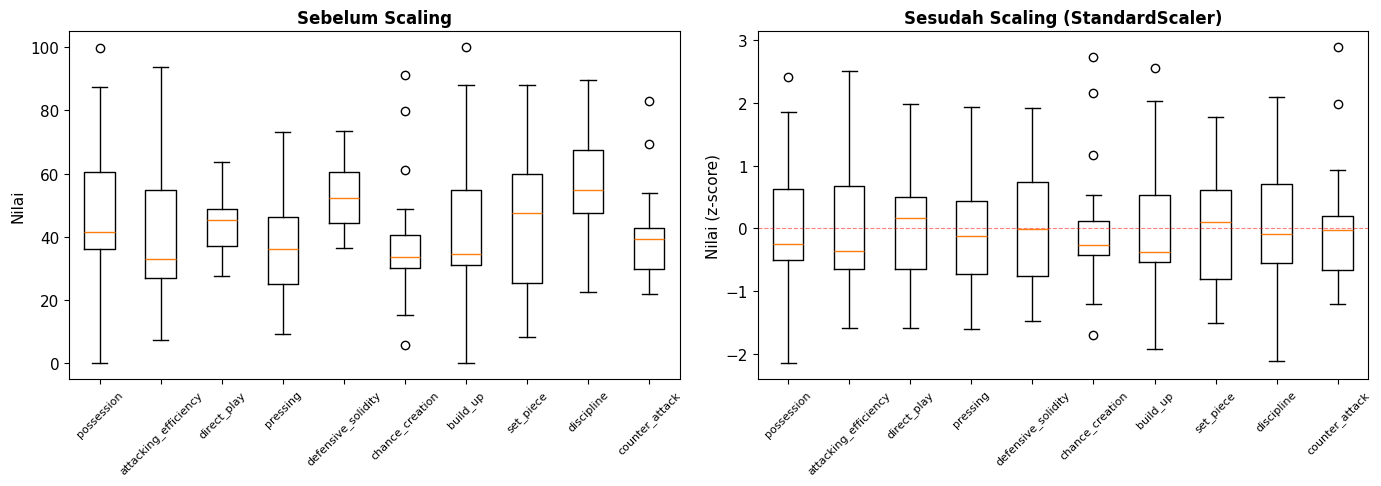

In [41]:
# --- Perbandingan visual sebelum vs sesudah ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum
axes[0].boxplot(X.values, labels=[c.replace("_score", "") for c in score_cols], vert=True)
axes[0].set_title("Sebelum Scaling", fontsize=12, fontweight="bold")
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].set_ylabel("Nilai")

# Sesudah
axes[1].boxplot(X_scaled, labels=[c.replace("_score", "") for c in score_cols], vert=True)
axes[1].set_title("Sesudah Scaling (StandardScaler)", fontsize=12, fontweight="bold")
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].set_ylabel("Nilai (z-score)")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

---

## 6. Menentukan Jumlah Cluster Optimal

Menentukan jumlah cluster (**k**) yang tepat merupakan langkah krusial dalam K-Means.  
Kita menggunakan **dua metode** yang saling melengkapi:

### 6.1 Elbow Method

Elbow Method mengukur **inertia** (total within-cluster sum of squares) untuk berbagai nilai k.  
Titik "siku" (*elbow*) pada grafik menunjukkan jumlah cluster dimana penambahan cluster selanjutnya tidak lagi memberikan penurunan inertia yang signifikan.

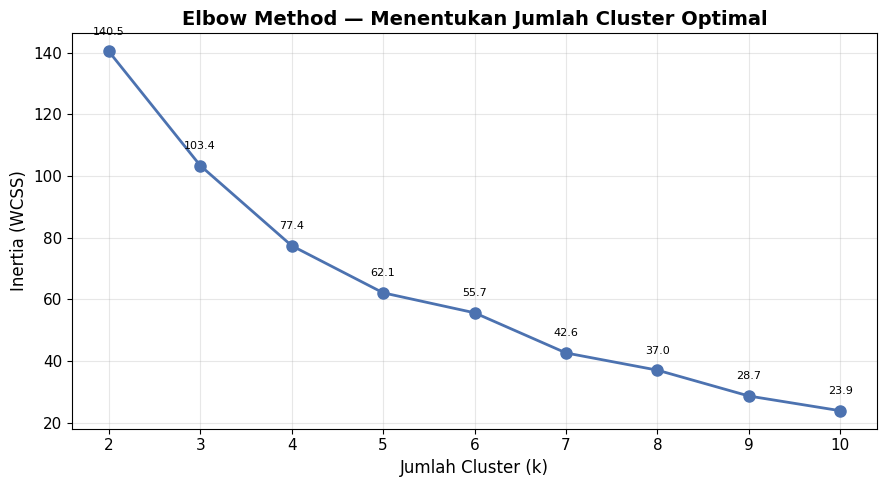


📊 Inertia per k:
   k = 2  →  Inertia = 140.47
   k = 3  →  Inertia = 103.43
   k = 4  →  Inertia = 77.42
   k = 5  →  Inertia = 62.14
   k = 6  →  Inertia = 55.65
   k = 7  →  Inertia = 42.63
   k = 8  →  Inertia = 37.04
   k = 9  →  Inertia = 28.66
   k = 10  →  Inertia = 23.88


In [42]:
# --- Elbow Method ---
K_RANGE = range(2, 11)

inertias = []
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Grafik
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_RANGE, inertias, marker='o', linewidth=2, markersize=8, color='#4C72B0')
ax.set_xlabel("Jumlah Cluster (k)", fontsize=12)
ax.set_ylabel("Inertia (WCSS)", fontsize=12)
ax.set_title("Elbow Method — Menentukan Jumlah Cluster Optimal", fontsize=14, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)

# Annotate setiap titik
for k, inertia in zip(K_RANGE, inertias):
    ax.annotate(f"{inertia:.1f}", (k, inertia), textcoords="offset points",
                xytext=(0, 12), fontsize=8, ha='center')

plt.tight_layout()
plt.show()

# Tabel
print("\n📊 Inertia per k:")
for k, inertia in zip(K_RANGE, inertias):
    print(f"   k = {k}  →  Inertia = {inertia:.2f}")

### 6.2 Silhouette Score

Silhouette Score mengukur seberapa **kohesif** anggota dalam satu cluster dan seberapa **terpisah** antar cluster.  
Nilai berkisar dari -1 (clustering sangat buruk) hingga +1 (clustering sangat baik).

- **Mendekati +1** → Cluster terpisah dengan jelas dan anggotanya kohesif.
- **Mendekati 0** → Cluster saling tumpang tindih.
- **Negatif** → Sampel berada di cluster yang salah.

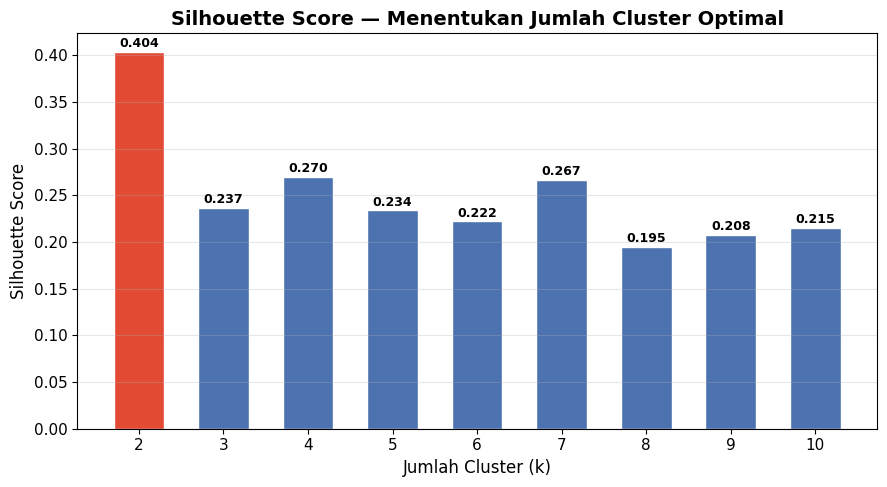


📊 Silhouette Score per k:
   k = 2  →  Silhouette = 0.4036 ◀ BEST
   k = 3  →  Silhouette = 0.2366
   k = 4  →  Silhouette = 0.2699
   k = 5  →  Silhouette = 0.2341
   k = 6  →  Silhouette = 0.2223
   k = 7  →  Silhouette = 0.2668
   k = 8  →  Silhouette = 0.1946
   k = 9  →  Silhouette = 0.2078
   k = 10  →  Silhouette = 0.2154


In [43]:
# --- Silhouette Score ---
silhouette_scores = []
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Grafik
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E24A33' if s == max(silhouette_scores) else '#4C72B0' for s in silhouette_scores]
ax.bar(K_RANGE, silhouette_scores, color=colors, edgecolor='white', width=0.6)
ax.set_xlabel("Jumlah Cluster (k)", fontsize=12)
ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Silhouette Score — Menentukan Jumlah Cluster Optimal", fontsize=14, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3, axis='y')

# Annotate
for k, s in zip(K_RANGE, silhouette_scores):
    ax.text(k, s + 0.005, f"{s:.3f}", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Tabel
best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
print(f"\n📊 Silhouette Score per k:")
for k, s in zip(K_RANGE, silhouette_scores):
    marker = " ◀ BEST" if k == best_k else ""
    print(f"   k = {k}  →  Silhouette = {s:.4f}{marker}")

### 6.3 Pemilihan Jumlah Cluster

Berdasarkan kombinasi kedua metode di atas, pilih jumlah cluster yang memberikan keseimbangan terbaik antara:
1. **Penurunan inertia yang signifikan** (elbow)
2. **Silhouette score tertinggi** (pemisahan cluster yang baik)
3. **Interpretabilitas** — jumlah cluster yang masuk akal secara domain sepakbola

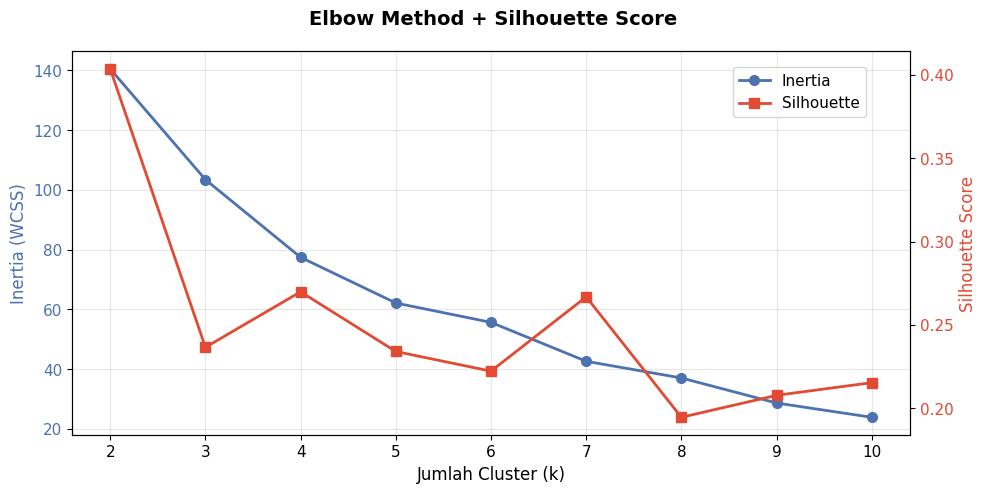

In [44]:
# --- Gabungan Elbow + Silhouette ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Elbow (sumbu kiri)
color1 = '#4C72B0'
ax1.plot(K_RANGE, inertias, marker='o', linewidth=2, markersize=7, color=color1, label='Inertia')
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(list(K_RANGE))

# Silhouette (sumbu kanan)
ax2 = ax1.twinx()
color2 = '#E24A33'
ax2.plot(K_RANGE, silhouette_scores, marker='s', linewidth=2, markersize=7, color=color2, label='Silhouette')
ax2.set_ylabel('Silhouette Score', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('Elbow Method + Silhouette Score', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# PILIH JUMLAH CLUSTER OPTIMAL
# ============================================================
# Ganti nilai OPTIMAL_K berdasarkan analisis Elbow + Silhouette
# di atas.

OPTIMAL_K = 4  # Sesuaikan jika diperlukan

print(f"✅ Jumlah cluster yang dipilih: k = {OPTIMAL_K}")
print(f"   Silhouette Score pada k={OPTIMAL_K}: {silhouette_scores[OPTIMAL_K - 2]:.4f}")

✅ Jumlah cluster yang dipilih: k = 4
   Silhouette Score pada k=4: 0.2699


---

## 7. Training K-Means

Setelah menentukan jumlah cluster optimal, kita melatih model K-Means final dengan parameter:
- `n_clusters` = jumlah cluster optimal
- `random_state = 42` — untuk reproducibility
- `n_init = 10` — menjalankan algoritma 10 kali dengan centroid awal berbeda, kemudian memilih hasil terbaik

In [59]:
# --- Training K-Means ---
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=RANDOM_STATE,
    n_init=10,
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Tambahkan label cluster ke dataset
df["cluster"] = cluster_labels

print(f"✅ K-Means training selesai.")
print(f"   Jumlah cluster  : {OPTIMAL_K}")
print(f"   Inertia         : {kmeans.inertia_:.2f}")
print(f"   Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"\n   Distribusi cluster:")
print(df["cluster"].value_counts().sort_index().to_string())

✅ K-Means training selesai.
   Jumlah cluster  : 4
   Inertia         : 77.42
   Silhouette Score: 0.2699

   Distribusi cluster:
cluster
0    10
1     2
2     6
3     2


In [60]:
# --- Cluster Centers (dalam skala asli 0-100) ---
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
df_centers = pd.DataFrame(centers_original, columns=score_cols)
df_centers.index.name = "Cluster"

print("📊 Cluster Centers (skala asli 0-100):")
df_centers.round(2)

📊 Cluster Centers (skala asli 0-100):


,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
Cluster,,,,,,,,,,
0,34.99,33.11,46.69,40.79,55.20,35.30,30.80,58.94,58.43,37.09
1,93.68,82.47,39.57,70.60,55.55,85.52,94.02,64.11,81.58,49.85
2,50.65,32.65,33.87,26.02,41.89,27.33,45.03,22.02,43.74,29.05
3,49.13,61.11,62.82,29.30,67.46,41.04,44.98,24.72,57.16,76.18


In [61]:
# --- Hasil Clustering: Klub dan Cluster ---
print("📋 Hasil Clustering:\n")
for cluster_id in sorted(df["cluster"].unique()):
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()
    print(f"   Cluster {cluster_id} ({len(clubs)} klub): {', '.join(clubs)}")

📋 Hasil Clustering:

   Cluster 0 (10 klub): Alaves, Athletic Bilbao, Atlético Madrid, Espanyol, Getafe, Levante, Osasuna, Rayo Vallecano, Real Sociedad, Valencia
   Cluster 1 (2 klub): Barcelona, Real Madrid
   Cluster 2 (6 klub): Celta Vigo, Elche, Girona, Mallorca, Real Oviedo, Sevilla
   Cluster 3 (2 klub): Real Betis, Villarreal


---

## 8. Cluster Profiling

Cluster profiling bertujuan memahami **karakteristik dominan** setiap cluster.  
Kita menghitung rata-rata setiap style score per cluster, kemudian memvisualisasikan hasilnya dalam bentuk heatmap dan tabel.

In [62]:
# --- Rata-rata style score per cluster ---
cluster_profile = df.groupby("cluster")[score_cols].mean().round(2)

print("📊 Cluster Profile — Rata-rata Style Scores:\n")
cluster_profile

📊 Cluster Profile — Rata-rata Style Scores:



,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
cluster,,,,,,,,,,
0,34.99,33.11,46.69,40.79,55.20,35.30,30.80,58.94,58.43,37.09
1,93.68,82.47,39.57,70.60,55.55,85.52,94.02,64.11,81.58,49.85
2,50.65,32.65,33.87,26.02,41.89,27.33,45.03,22.02,43.74,29.05
3,49.13,61.11,62.82,29.30,67.46,41.04,44.98,24.72,57.16,76.18


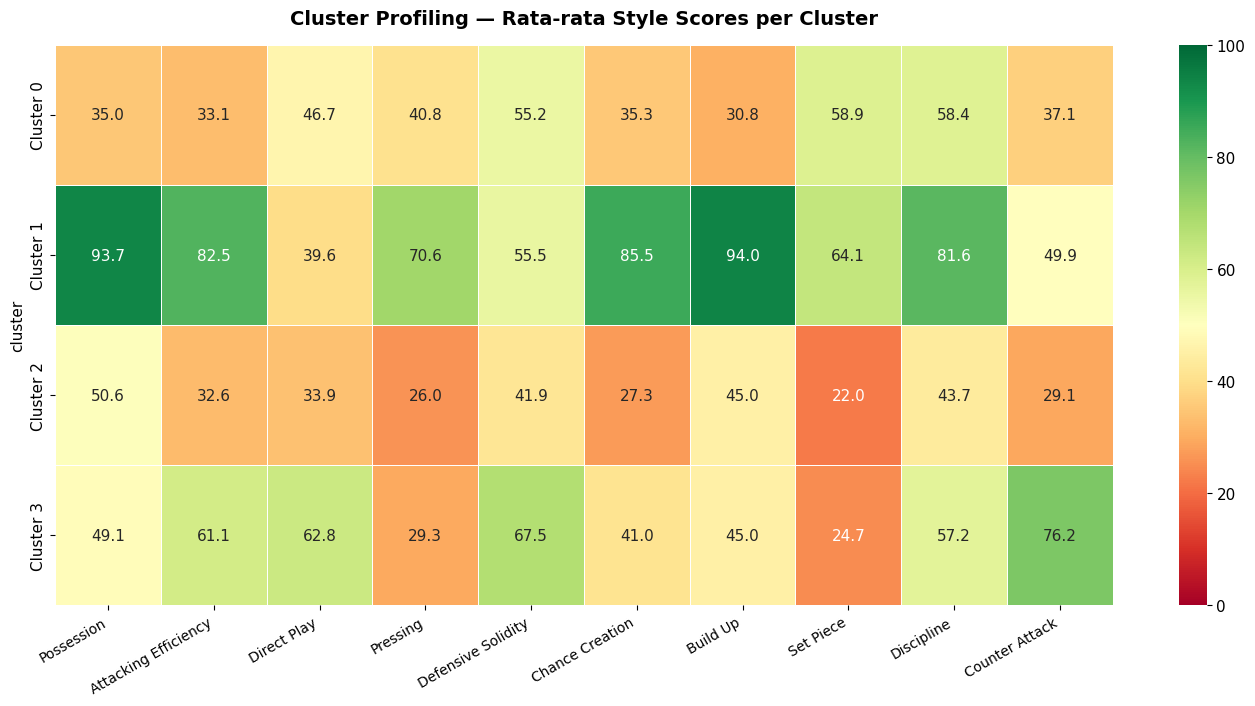

In [63]:
# --- Heatmap: Cluster Profiling ---
short_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

fig, ax = plt.subplots(figsize=(14, 4 + OPTIMAL_K * 0.8))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    xticklabels=short_labels,
    yticklabels=[f"Cluster {i}" for i in cluster_profile.index],
    linewidths=0.5,
    vmin=0, vmax=100,
    ax=ax,
)

ax.set_title("Cluster Profiling — Rata-rata Style Scores per Cluster",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [64]:
# --- Interpretasi otomatis: dimensi terkuat per cluster ---
print("🔍 Karakteristik Dominan per Cluster:\n")
for cluster_id in sorted(cluster_profile.index):
    row = cluster_profile.loc[cluster_id]
    top_3 = row.nlargest(3)
    bottom_3 = row.nsmallest(3)
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()

    print(f"   Cluster {cluster_id} — {len(clubs)} klub: {', '.join(clubs)}")
    print(f"      🟢 Kekuatan  : {', '.join([f'{c.replace(chr(95)+chr(115)+chr(99)+chr(111)+chr(114)+chr(101), chr(0)).replace(chr(95), chr(32)).strip()} ({v:.1f})' for c, v in top_3.items()])}")
    print(f"      🔴 Kelemahan : {', '.join([f'{c.replace(chr(95)+chr(115)+chr(99)+chr(111)+chr(114)+chr(101), chr(0)).replace(chr(95), chr(32)).strip()} ({v:.1f})' for c, v in bottom_3.items()])}")
    print()

🔍 Karakteristik Dominan per Cluster:

   Cluster 0 — 10 klub: Alaves, Athletic Bilbao, Atlético Madrid, Espanyol, Getafe, Levante, Osasuna, Rayo Vallecano, Real Sociedad, Valencia
      🟢 Kekuatan  : set piece  (58.9), discipline  (58.4), defensive solidity  (55.2)
      🔴 Kelemahan : build up  (30.8), attacking efficiency  (33.1), possession  (35.0)

   Cluster 1 — 2 klub: Barcelona, Real Madrid
      🟢 Kekuatan  : build up  (94.0), possession  (93.7), chance creation  (85.5)
      🔴 Kelemahan : direct play  (39.6), counter attack  (49.9), defensive solidity  (55.5)

   Cluster 2 — 6 klub: Celta Vigo, Elche, Girona, Mallorca, Real Oviedo, Sevilla
      🟢 Kekuatan  : possession  (50.6), build up  (45.0), discipline  (43.7)
      🔴 Kelemahan : set piece  (22.0), pressing  (26.0), chance creation  (27.3)

   Cluster 3 — 2 klub: Real Betis, Villarreal
      🟢 Kekuatan  : counter attack  (76.2), defensive solidity  (67.5), direct play  (62.8)
      🔴 Kelemahan : set piece  (24.7), pressing

---

## 9. Visualisasi Cluster — PCA Scatter Plot

Karena kita memiliki 10 dimensi fitur, diperlukan **reduksi dimensi** agar cluster dapat divisualisasikan dalam 2D.  
**PCA (Principal Component Analysis)** mereduksi 10 style scores menjadi 2 komponen utama yang menangkap variasi data terbesar.

Setiap titik mewakili satu klub, diwarnai berdasarkan cluster yang dihasilkan K-Means.

In [65]:
# --- PCA: Reduksi ke 2D ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

print(f"📐 PCA Explained Variance:")
print(f"   PC1: {ev1:.1f}%")
print(f"   PC2: {ev2:.1f}%")
print(f"   Total: {ev1 + ev2:.1f}%")

📐 PCA Explained Variance:
   PC1: 43.8%
   PC2: 23.9%
   Total: 67.7%


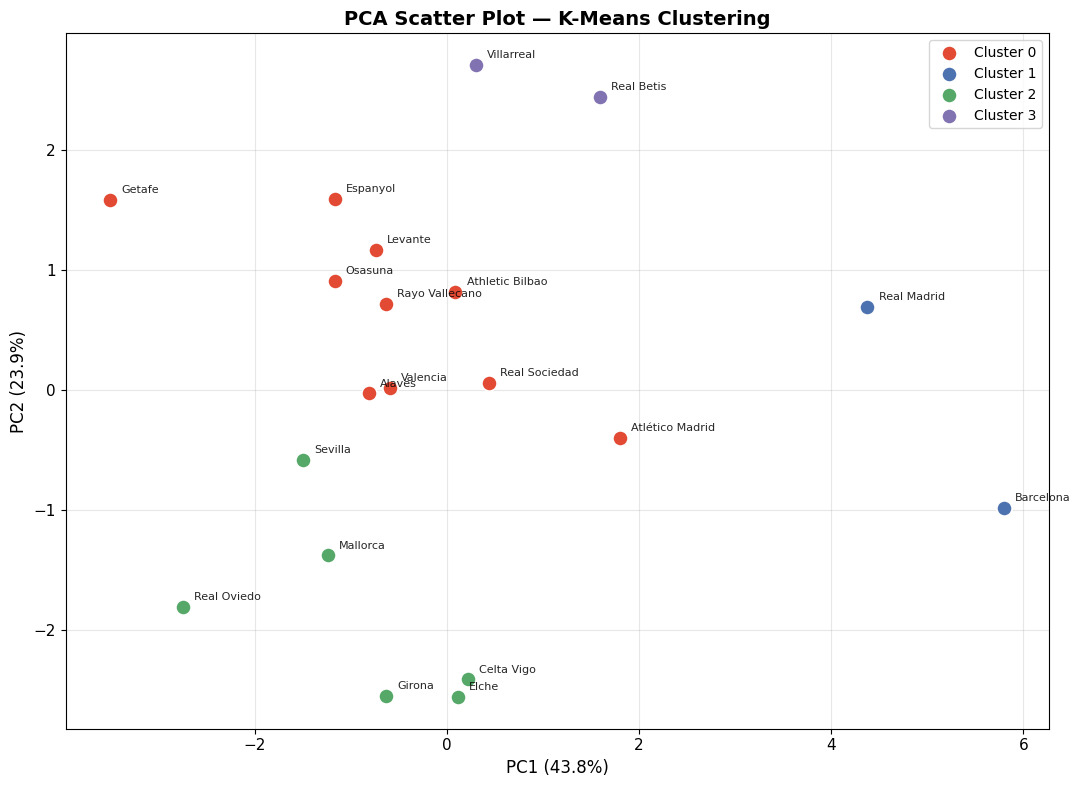

In [66]:
# --- PCA Scatter Plot (diberi warna per cluster) ---
cluster_colors = ['#E24A33', '#4C72B0', '#55A868', '#8172B2', '#C44E52',
                  '#CCB974', '#64B5CD', '#8C8C8C', '#FF9F1C', '#2EC4B6']

fig, ax = plt.subplots(figsize=(11, 8))

for cluster_id in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        s=120,
        label=f"Cluster {cluster_id}",
        edgecolors='white',
        linewidth=1.2,
        zorder=3,
    )

# Label nama klub
for i, club in enumerate(df["club"]):
    ax.annotate(
        club, (X_pca[i, 0], X_pca[i, 1]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=8,
        alpha=0.85,
    )

ax.set_xlabel(f"PC1 ({ev1:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev2:.1f}%)", fontsize=12)
ax.set_title("PCA Scatter Plot — K-Means Clustering", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 10. Radar Chart per Cluster

Radar chart menampilkan **profil rata-rata** setiap cluster di seluruh 10 dimensi style scoring.  
Visualisasi ini memudahkan perbandingan karakteristik antar cluster:
- Cluster dengan tonjolan di sisi kiri (possession, build-up) → cenderung possession-based.
- Cluster dengan tonjolan di sisi kanan (direct play, counter attack) → cenderung bermain langsung.

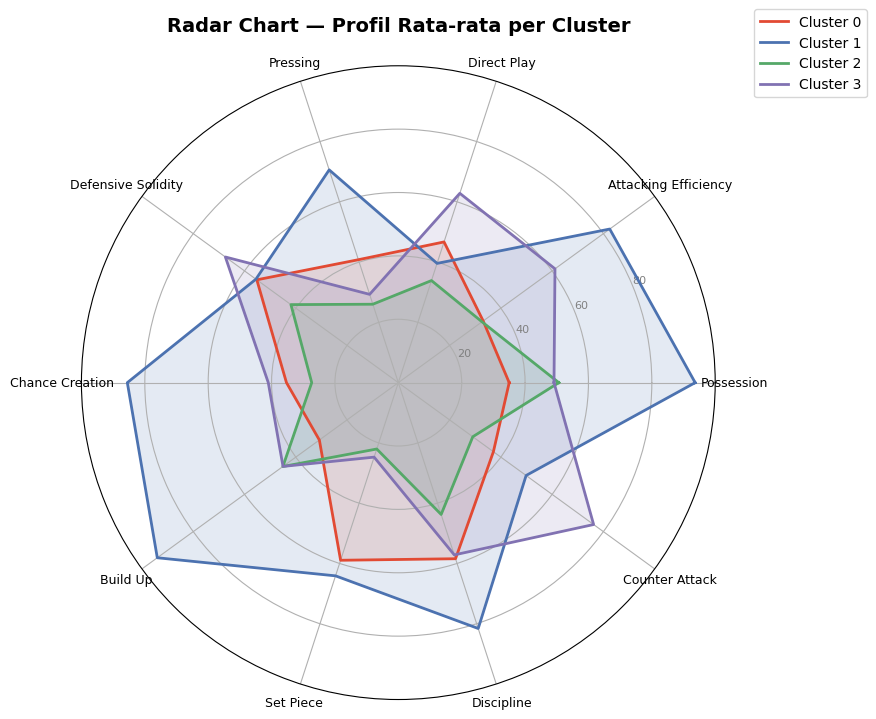

In [67]:
# --- Radar Chart per Cluster ---
labels_radar = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]
num_vars = len(score_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Tutup lingkaran

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cluster_id in sorted(cluster_profile.index):
    values = cluster_profile.loc[cluster_id].tolist()
    values += values[:1]  # Tutup lingkaran

    ax.fill(angles, values, alpha=0.15, color=cluster_colors[cluster_id])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cluster_id],
            label=f"Cluster {cluster_id}")

ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(["20", "40", "60", "80"], fontsize=8, color="gray")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_title("Radar Chart — Profil Rata-rata per Cluster",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

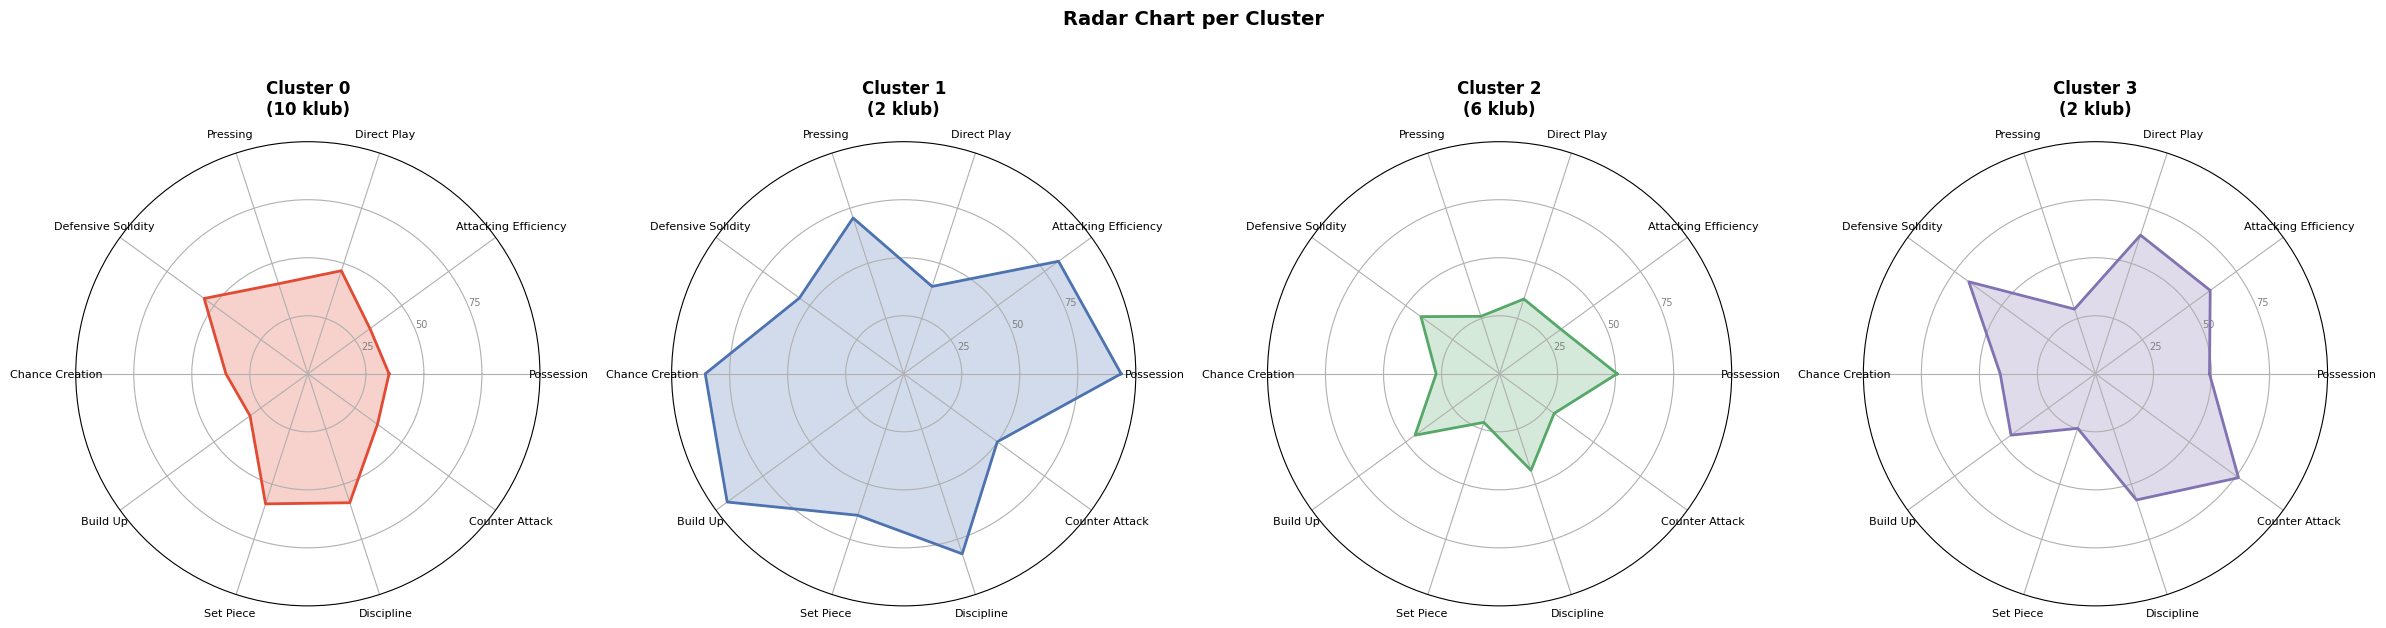

In [68]:
# --- Radar Chart: Masing-masing cluster terpisah ---
n_clusters = len(cluster_profile)
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6),
                         subplot_kw=dict(polar=True))

if n_clusters == 1:
    axes = [axes]

for cluster_id, ax in zip(sorted(cluster_profile.index), axes):
    values = cluster_profile.loc[cluster_id].tolist()
    values += values[:1]
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()

    ax.fill(angles, values, alpha=0.25, color=cluster_colors[cluster_id])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cluster_id])
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=7, color="gray")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar, fontsize=8)
    ax.set_title(f"Cluster {cluster_id}\n({len(clubs)} klub)",
                 fontsize=12, fontweight="bold", pad=20)

plt.suptitle("Radar Chart per Cluster", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

---

## 11. Analisis Klub

Pada bagian ini, kita menampilkan **detail setiap klub** beserta cluster dan seluruh style score-nya.  
Interpretasi singkat diberikan berdasarkan posisi klub dalam cluster dan nilai score-nya.

In [56]:
# --- Tabel lengkap: Klub + Cluster + Scores ---
df_result = df[["club", "cluster"] + score_cols].sort_values(
    ["cluster", "club"]
).reset_index(drop=True)

df_result

,club,cluster,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
0,Alaves,0,36.07,29.19,38.65,42.75,58.82,30.49,30.53,55.21,61.87,27.11
1,Athletic Bilbao,0,36.19,26.54,47.68,73.22,61.00,48.81,32.40,34.02,54.28,38.08
2,Atlético Madrid,0,64.13,58.54,38.98,35.33,58.04,61.09,61.77,51.70,70.46,33.93
3,Celta Vigo,0,64.03,54.75,31.21,22.05,47.38,34.87,62.05,8.21,48.11,23.52
4,Elche,0,63.64,39.11,27.77,45.09,38.68,31.56,54.86,10.18,47.61,30.88
5,Espanyol,0,22.15,27.07,57.27,36.85,44.60,31.53,20.89,87.36,66.39,41.80
6,Getafe,0,0.00,14.26,47.46,33.31,73.37,5.79,0.00,66.52,45.42,22.48
7,Girona,0,59.66,26.94,30.45,14.34,37.45,30.88,54.86,21.89,55.24,26.44
8,Levante,0,24.73,33.77,51.66,33.14,38.26,33.25,22.52,88.06,74.70,47.15
9,Mallorca,0,37.97,36.99,38.78,16.19,36.38,26.22,33.78,26.67,58.14,31.05


In [57]:
# --- Analisis per klub ---
print("📋 Analisis Klub per Cluster")
print("=" * 80)

for cluster_id in sorted(df["cluster"].unique()):
    cluster_data = df[df["cluster"] == cluster_id].sort_values("club")
    cluster_mean = cluster_profile.loc[cluster_id]
    top_style = cluster_mean.idxmax().replace("_score", "").replace("_", " ").title()

    print(f"\n── Cluster {cluster_id} (Ciri utama: {top_style}) ──")
    print(f"   Jumlah klub: {len(cluster_data)}")
    print()

    for _, row in cluster_data.iterrows():
        club = row["club"]
        scores = row[score_cols]
        top_2 = scores.nlargest(2)
        top_str = ", ".join([f"{c.replace('_score', '').replace('_', ' ').title()} ({v:.1f})" for c, v in top_2.items()])
        print(f"   • {club:<20s} → Keunggulan: {top_str}")

print("\n" + "=" * 80)

📋 Analisis Klub per Cluster

── Cluster 0 (Ciri utama: Discipline) ──
   Jumlah klub: 18



TypeError: Cannot use method 'nlargest' with dtype object

---

## 12. Simpan Hasil

Simpan dataset final yang sudah dilengkapi label cluster untuk digunakan pada tahap analisis berikutnya (dashboard, visualisasi, laporan).

In [ ]:
# --- Simpan ke CSV ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"
output_path = output_dir / "teams_clustered.csv"

df_output = df[["club", "cluster"] + score_cols].sort_values("club")
df_output.to_csv(output_path, index=False)

print(f"✅ Dataset disimpan ke: {output_path}")
print(f"   Shape: {df_output.shape}")
print(f"   Kolom: {list(df_output.columns)}")

---

## 13. Kesimpulan

### Hasil Clustering

Algoritma **K-Means Clustering** berhasil mengelompokkan 20 klub La Liga berdasarkan 10 dimensi gaya bermain.

**Parameter:**
- Jumlah cluster optimal ditentukan menggunakan **Elbow Method** dan **Silhouette Score**.
- Scaling menggunakan **StandardScaler** untuk memastikan kontribusi fitur proporsional.
- `random_state = 42` untuk reproducibility.

### Penggunaan Hasil Clustering

1. **Dashboard Analitik** — Visualisasi interaktif yang menampilkan profil gaya bermain per cluster, memudahkan analis untuk membandingkan dan mengidentifikasi pola.
2. **Scouting & Strategi** — Memahami kecenderungan taktis lawan berdasarkan cluster-nya untuk menyusun strategi pertandingan.
3. **Analisis Liga** — Mengidentifikasi tren gaya bermain dominan di liga dan bagaimana keragaman taktis mempengaruhi kompetisi.
4. **Riset Akademis** — Memberikan kerangka kuantitatif untuk mendeskripsikan dan membandingkan gaya bermain tim secara objektif.

### File Output
- `data/ml_ready/teams_clustered.csv` — Dataset final berisi club, cluster label, dan 10 style scores.